## Multi-dimensional OU process

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'         
plt.rcParams['font.serif'] = ['Computer Modern Serif']  
import scipy as sp
import time
import sys
sys.path.append("/home/s2421480/Documents/PhD_first_year/Extended_summer_project/Codes/d3s/")
import ranndy_jax
import plotter
from plotter import *
import importlib
importlib.reload(ranndy_jax)
importlib.reload(plotter)
from ranndy_jax import RaNNDy, VAMPNets
import d3s.domain as domain
import d3s.algorithms as algorithms
import d3s.observables as observables
#import deeptime as dt
plt.ion()

In [2]:
dim = 2
A = np.zeros((dim, dim))

for i in range(dim):
    A[i, i] = 2

for i in range(dim - 1):
    A[i, i + 1] = -(i + 1) / dim
    A[i + 1, i] = -(i + 1) / dim

print("A", A)
A = -A

# A = np.array([[-1.5, 1], [0, -2.0]])
da, Va = np.linalg.eig(A)
print('Eigvals of A: ', da)

np.random.seed(0)

dt = 0.1
n_steps = 50000

sigma = 0.25

traj = np.zeros((n_steps, dim))


for t in range(n_steps - 1):
    dW = np.sqrt(dt) * np.random.randn(dim)
    traj[t+1] = traj[t] + A @ traj[t] * dt + np.sqrt(sigma) * dW

X = traj[:-1:1].T
Y = traj[1::1].T

psi = observables.monomials(3)

K, dk, Vk = algorithms.edmd(X, Y, psi, operator='K')

eigf = Vk.T @ psi(X)

print('Koopman generator d:', np.log(dk) / dt)

eigmat = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        eigmat[i, j] = i*da[0] + j*da[1]

print(eigmat)

A [[ 2.  -0.5]
 [-0.5  2. ]]
Eigvals of A:  [-1.5 -2.5]
Koopman generator d: [ 8.88178420e-15+0.j -1.61951650e+00+0.j -2.89009524e+00+0.j
 -3.25891801e+00+0.j -4.42003610e+00+0.j]
[[ -0.   -2.5  -5.   -7.5 -10. ]
 [ -1.5  -4.   -6.5  -9.  -11.5]
 [ -3.   -5.5  -8.  -10.5 -13. ]
 [ -4.5  -7.   -9.5 -12.  -14.5]
 [ -6.   -8.5 -11.  -13.5 -16. ]]


In [3]:
exact_eigvals_g = np.array([0, -1.5, -2.5, -3.0, -4])
exact_eigvals_o = np.exp(exact_eigvals_g * dt)
print('Exact eigenvalues of operator: ', exact_eigvals_o)
print('Sum of exact eigenvalues of operator: ', np.sum(exact_eigvals_o))

Exact eigenvalues of operator:  [1.         0.86070798 0.77880078 0.74081822 0.67032005]
Sum of exact eigenvalues of operator:  4.05064702621382


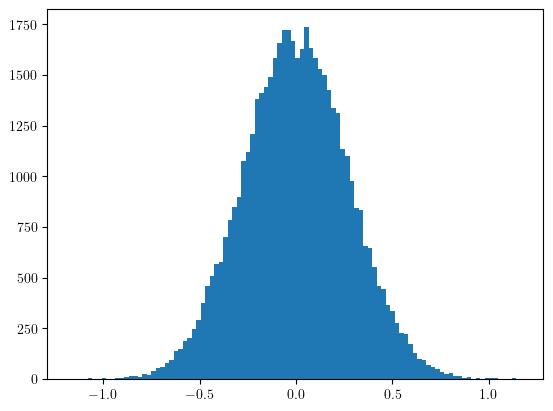

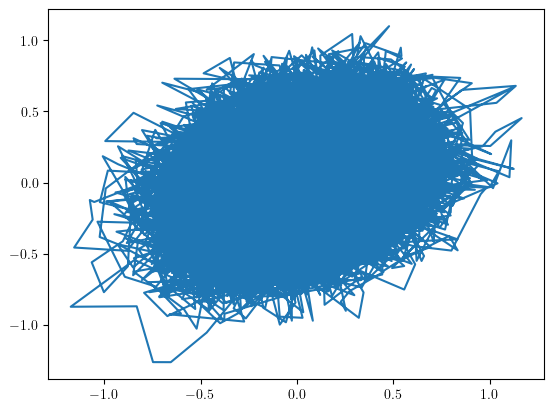

In [4]:
plt.hist(X[0, :], bins=100)
plt.show()

plt.plot(X[0, :], X[1, :])

## RaNNDy

In [25]:
## Run this cell to apply RaNNDy for the Koopman operator

operator = 'koopman'
hidden_sizes = [256, 512, 256]  # Hidden layer sizes
final_size = 5  # Output layer size
activation = "tanh"  # activation function
init_weights = 'lecun_normal'
init_bias = 'normal'  # Initialization of weights and biases
init_weights_std = 1.0  # Standard deviation for normal initialization
init_bias_std = 0.1  # Scale for uniform initialization
# direct_link=False  # Whether to use direct link to input # TODO:
random_state = 0  # Random state for reproducibility
n_eigfuncs = final_size  # Number of eigenfunctions to compute
kwargs = {} # only needed for Hamiltonian operator

ranndy = RaNNDy(
    X=X,
    operator=operator,
    hidden_sizes=hidden_sizes,
    final_size=final_size,
    activation=activation,
    init_weights_dist=init_weights, 
    init_weights_std=init_weights_std,
    init_bias_dist=init_bias,
    init_bias_std=init_bias_std,
    #direct_link=direct_link,
    random_state=random_state,
)

start_time = time.time()  # Start time for RNN eigendecomposition
# eigvals and eigenvectors approximation
Kr, eigvals_rnn, eigvecs_rnn = ranndy.operator_eig_decomp(
    X=X,
    Y=Y,
    Z=None,
    params=None,
    n=n_eigfuncs,
    epsilon=1e-5,
    kwargs=kwargs)

end_time = time.time()  # End time for RNN eigendecomposition
time_rnn = end_time - start_time
print(f"RNN eigendecomposition time: {time_rnn:.2f} seconds")

RNN eigendecomposition time: 0.87 seconds


## VAMPnets

In [ ]:
## Run this cell to apply VAMPnets for Koopman operator

vampnet = VAMPNets(X=X, 
                   hidden_sizes=[256, 512, 256],
                   final_size=5,
                   activation='tanh',
                   init_weights_dist='normal', 
                   init_weights_std=init_weights_std,
                   init_bias_dist=init_bias,
                   init_bias_std=init_bias_std,
                   #randomized=False,
                   batch_norm=False,
                   random_state=random_state, vampnet=True)

## Operator eigendecomposition using VAMPNet

epochs = [20, 40, 60, 80, 100, 120]  # Number of epochs for training
traces_vampnet = []
run_times = []

lr = 1e-2  # Learning rate for the optimizer; large lr leads to nan values so keep it small
optim = 'adam'  # Optimizer for training VAMPNet

for epoch in epochs:
   start_time = time.time()  # Start time for VAMPNet eigendecomposition

   params, loss = vampnet.training(X=X, Y=Y, n=n_eigfuncs, epochs=epoch, optim=optim, lr=lr, epsilon=1e-5)

   end_time = time.time()  # End time for VAMPNet eigendecomposition
   time_vampnet = end_time - start_time
   run_times.append(time_vampnet)
   traces_vampnet.append(loss[-1])
   print(f"VAMPNet eigendecomposition time: {time_vampnet:.2f} seconds")

## eigenfunctions using VAMPNet

Kv, eigvals_vampnet, eigvecs_vampnet = vampnet.koopman_approximation(params=params,
    X=X,
    Y=Y, n=n_eigfuncs)

Epoch 0, Loss: -2.9173
Epoch 10, Loss: -3.0834
VAMPNet eigendecomposition time: 73.18 seconds
Epoch 0, Loss: -2.8897
Epoch 10, Loss: -3.0886
Epoch 20, Loss: -3.2002
Epoch 30, Loss: -3.2681
VAMPNet eigendecomposition time: 150.39 seconds
Epoch 0, Loss: -2.9865
Epoch 10, Loss: -3.1970
Epoch 20, Loss: -3.2919
Epoch 30, Loss: -3.3326
Epoch 40, Loss: -3.3950
Epoch 50, Loss: -3.4546
VAMPNet eigendecomposition time: 250.51 seconds
Epoch 0, Loss: -3.0054
Epoch 10, Loss: -3.2170
Epoch 20, Loss: -3.3329
Epoch 30, Loss: -3.4111
Epoch 40, Loss: -3.4376
Epoch 50, Loss: -3.4778
Epoch 60, Loss: -3.4842
Epoch 70, Loss: -3.5226
VAMPNet eigendecomposition time: 300.53 seconds
Epoch 0, Loss: -2.9584
Epoch 10, Loss: -3.2805
Epoch 20, Loss: -3.4096
Epoch 30, Loss: -3.4556
Epoch 40, Loss: -3.5093
Epoch 50, Loss: -3.5262
Epoch 60, Loss: -3.5298
Epoch 70, Loss: -3.5694
Epoch 80, Loss: -3.5932
Epoch 90, Loss: -3.5936
VAMPNet eigendecomposition time: 362.80 seconds
Epoch 0, Loss: -2.9942
Epoch 10, Loss: -3.3714

In [27]:
print('eigvals of RaNNDy and sum their sum', np.log(eigvals_rnn) / dt, np.sum(eigvals_rnn))
print('Trace of Kr: ', np.trace(Kr))

print('eigvals of VAMPnets and sum their sum', np.log(eigvals_vampnet) / dt, np.sum(eigvals_vampnet))
print('Trace of Kv: ', np.trace(Kv))

eigvals of RaNNDy and sum their sum [-0.00771045+0.j -1.6745074 +0.j -2.9326434 +0.j -5.224188  +0.j
 -6.0437965 +0.j] (3.73037+0j)
Trace of Kr:  3.7303696
eigvals of VAMPnets and sum their sum [ 3.5762782e-06+0.j -2.2542355e+00+0.j -3.9215493e+00+0.j
 -4.5246739e+00+0.j -5.4694767e+00+0.j] (3.6885483+0j)
Trace of Kv:  3.6885476


In [26]:
print('Eigenvalues Exact: ', exact_eigvals_o)
print('Eigenvalues RaNNDy: ', eigvals_rnn)
print('Eigenvalues VAMPnets: ', eigvals_vampnet)


Eigenvalues Exact:  [1.         0.86070798 0.77880078 0.74081822 0.67032005]
Eigenvalues RaNNDy:  [0.99922925+0.j 0.8458183 +0.j 0.745825  +0.j 0.5930843 +0.j
 0.5464133 +0.j]
Eigenvalues VAMPnets:  [1.0000004 +0.j 0.7981781 +0.j 0.67559946+0.j 0.6360568 +0.j
 0.5787136 +0.j]


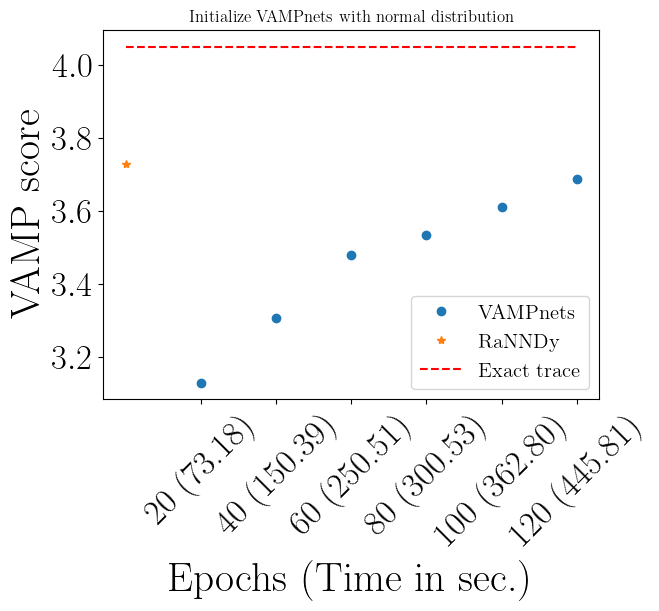

In [ ]:
plt.figure()
plt.plot(epochs, np.array(traces_vampnet), 'o', label='VAMPnets')
plt.plot(np.trace(Kr), '*', label='RaNNDy')
plt.hlines(np.sum(exact_eigvals_o), xmin=0, xmax=epochs[-1], colors='red', linestyles='--', label='Exact trace')
plt.xlabel("Epochs (Time in sec.)", fontsize=30)
plt.ylabel("VAMP score", fontsize=30)
plt.legend(fontsize=15, loc='lower right')
labels = [f"{e} ({t:.2f})" for e, t in zip(epochs, run_times)]
plt.xticks(epochs, labels, rotation=45, fontsize=25)
plt.yticks(fontsize=25)
plt.title('Initialize VAMPnets with normal distribution')
#plt.savefig("../figures/ou2dcomp_normal.pdf", bbox_inches="tight",dpi=300)
plt.show()
